In [1]:
!pip install -q tensorflow scikit-learn pandas matplotlib tabulate

In [2]:
!pip -q install librosa soundfile scikit-learn pandas seaborn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/Project Work/archive 1.zip"
extract_to = "/content/Bangla_Emotion_Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted successfully!")

Extracted successfully!


In [5]:
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import librosa
import librosa.display
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, Model, regularizers

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Your actual dataset root from the screenshot
DATASET_DIR = "/content/Bangla_Emotion_Dataset/archive 1/archive/archive/Emotions"

# Output files
FINAL_MODEL_PATH = "/content/bangla_cnn_transformer_emotion.keras"
BEST_MODEL_PATH = "/content/bangla_cnn_transformer_best.keras"
LABEL_JSON_PATH = "/content/bangla_emotion_labels.json"

# Folder names exactly as they exist
FOLDER_NAMES = ["Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad", "Surprised"]

# Fix folder typo here
FOLDER_TO_LABEL = {
    "Angry": "Angry",
    "Disgusted": "Disgusted",
    "Fearful": "Fearful",
    "Happy": "Happy",
    "Neutral": "Neutral",
    "Sad": "Sad",
    "Surprised": "Surprised"
}

# Final label order for the model
LABELS = ["Angry", "Happy", "Neutral", "Sad", "Disgusted", "Fearful", "Surprised"]
label_to_idx = {label: i for i, label in enumerate(LABELS)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

# Audio settings
SR = 16000
DURATION = 4
SAMPLES = SR * DURATION

# Feature settings
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

# Training settings
BATCH_SIZE = 32
EPOCHS = 60
AUG_PER_FILE = 1   # 1 extra augmented copy per training file

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Folders inside dataset root:")
print(os.listdir(DATASET_DIR))

Dataset exists: True
Folders inside dataset root:
['Disgusted', 'Sad', 'Surprised', 'Neutral', 'Fearful', 'Happy', 'Angry']


In [8]:
audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.m4a', '.mp4']
rows = []

for folder_name in FOLDER_NAMES:
    class_dir = os.path.join(DATASET_DIR, folder_name)
    if not os.path.isdir(class_dir):
        print(f'Missing folder: {class_dir}')
        continue

    final_label = FOLDER_TO_LABEL[folder_name]
    for root, _, files in os.walk(class_dir):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in audio_extensions:
                rows.append({
                    'filepath': os.path.join(root, file),
                    'folder_name': folder_name,
                    'label': final_label,
                    'label_id': label_to_idx[final_label]
                })

df = pd.DataFrame(rows)
print(f'Total files: {len(df)}')
display(df['label'].value_counts())
display(df.head())

Total files: 7000


,count
label,
Angry,1000
Disgusted,1000
Fearful,1000
Happy,1000
Neutral,1000
Sad,1000
Surprised,1000


,filepath,folder_name,label,label_id
0,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
1,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
2,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
3,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
4,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0


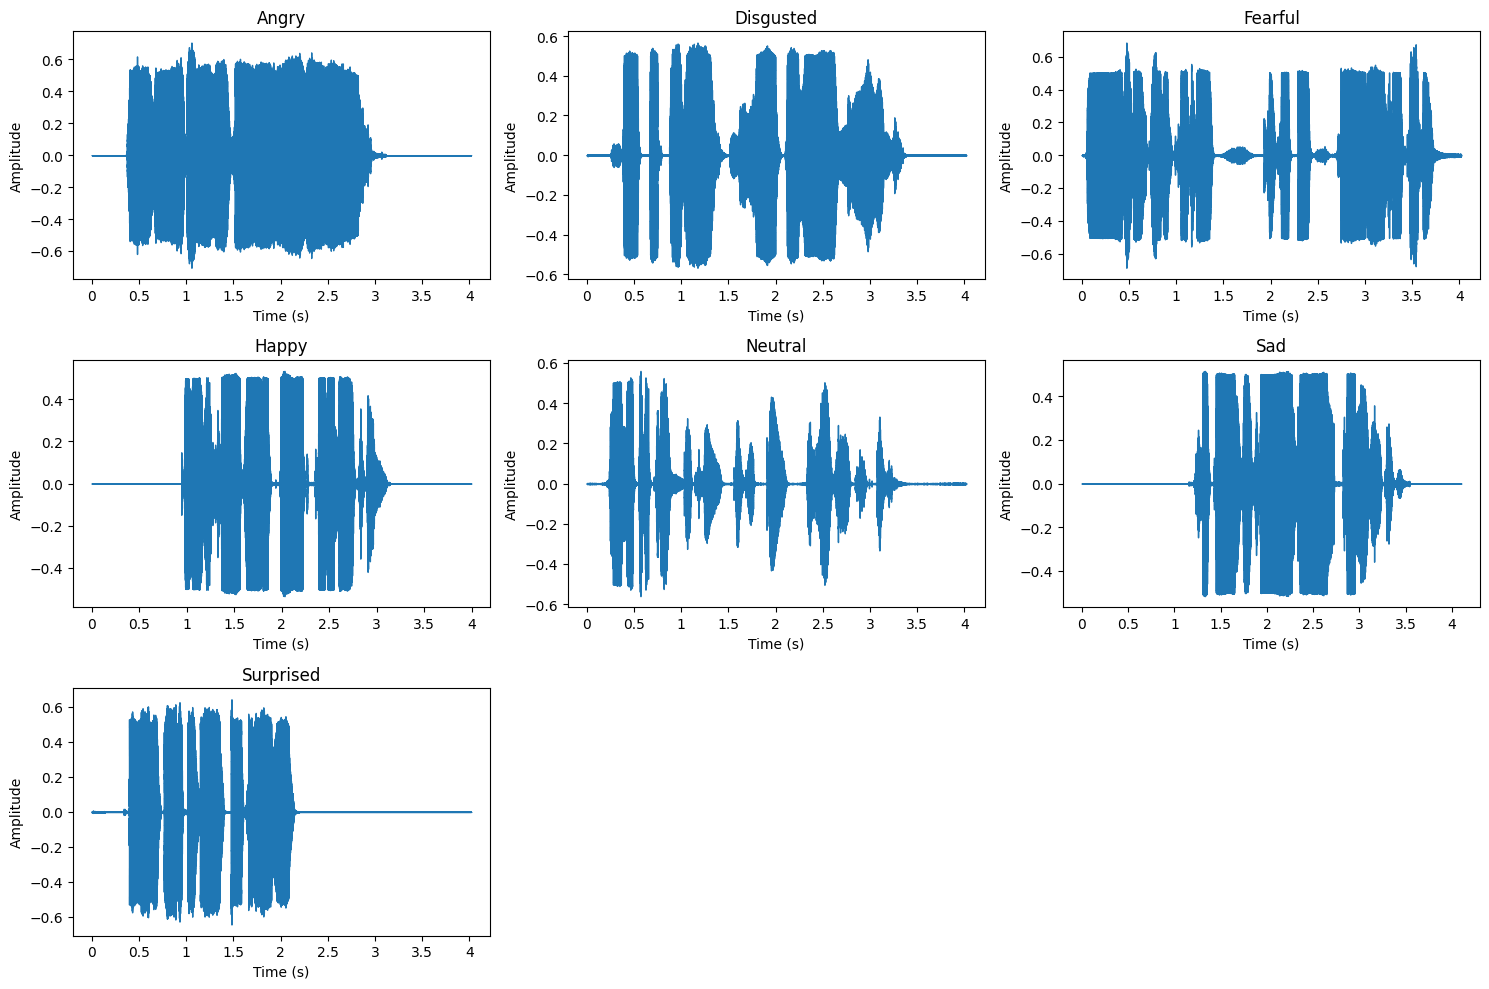

In [9]:
data_path = "/content/Bangla_Emotion_Dataset/archive 1/archive/archive/Emotions" # Updated path to the emotion folders
emotions = ["Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad", "Surprised"]

sample_files = {emotion: os.path.join(data_path, emotion, os.listdir(os.path.join(data_path, emotion))[0]) for emotion in emotions}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(9):
    if i < len(emotions):
        emotion = emotions[i]
        file_path = sample_files[emotion]
        y, sr = librosa.load(file_path)
        librosa.display.waveshow(y, sr=sr, ax=axes[i])
        axes[i].set_title(emotion)
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Amplitude")
    else:
        axes[i].axis("off")

plt.tight_layout()
plt.show()

# Plotting a bar chart of sample counts per emotion class.

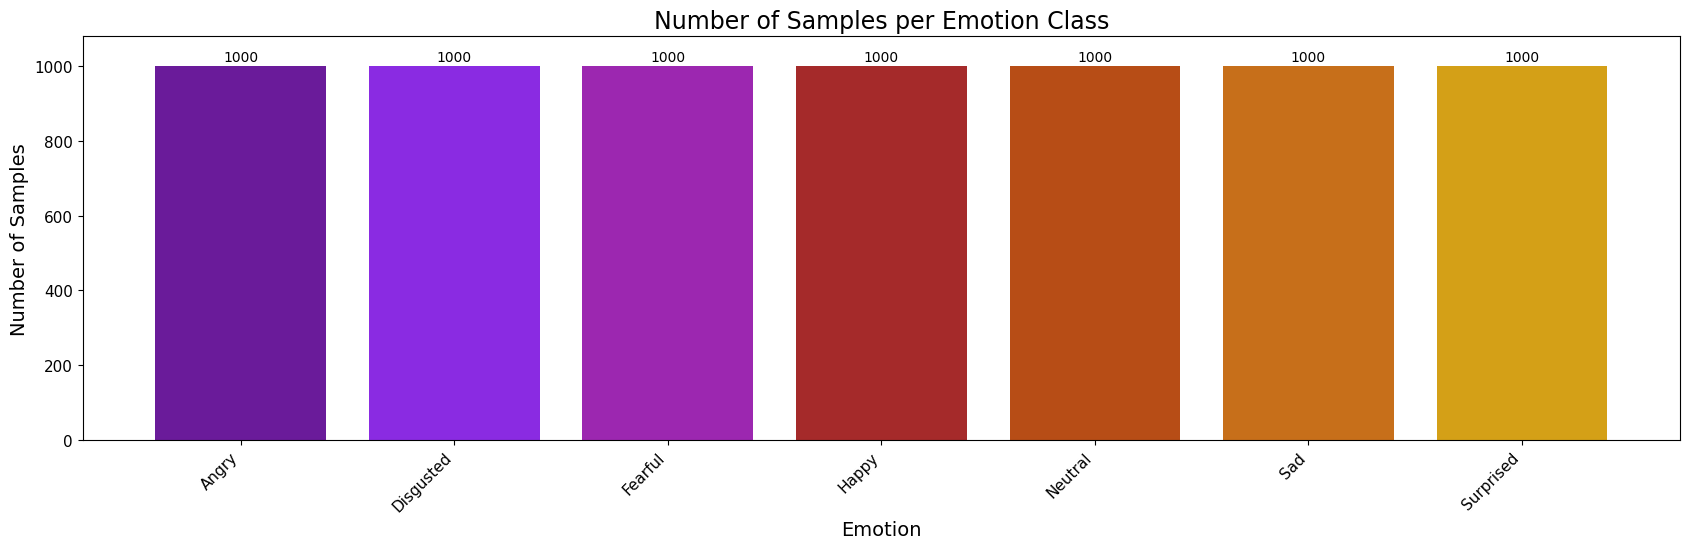

In [10]:
import matplotlib.pyplot as plt

emotion_order = ["Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad", "Surprised"]
emotion_counts = df["label"].value_counts().reindex(emotion_order, fill_value=0)

colors = ["#6A1B9A", "#8A2BE2", "#9C27B0", "#A52A2A", "#B74D16", "#C76F1A", "#D4A017"]

plt.figure(figsize=(17, 5.6))
bars = plt.bar(emotion_counts.index, emotion_counts.values, color=colors)

plt.title("Number of Samples per Emotion Class", fontsize=17)
plt.xlabel("Emotion", fontsize=14)
plt.ylabel("Number of Samples", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, max(emotion_counts.values) * 1.08)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Spectrogram

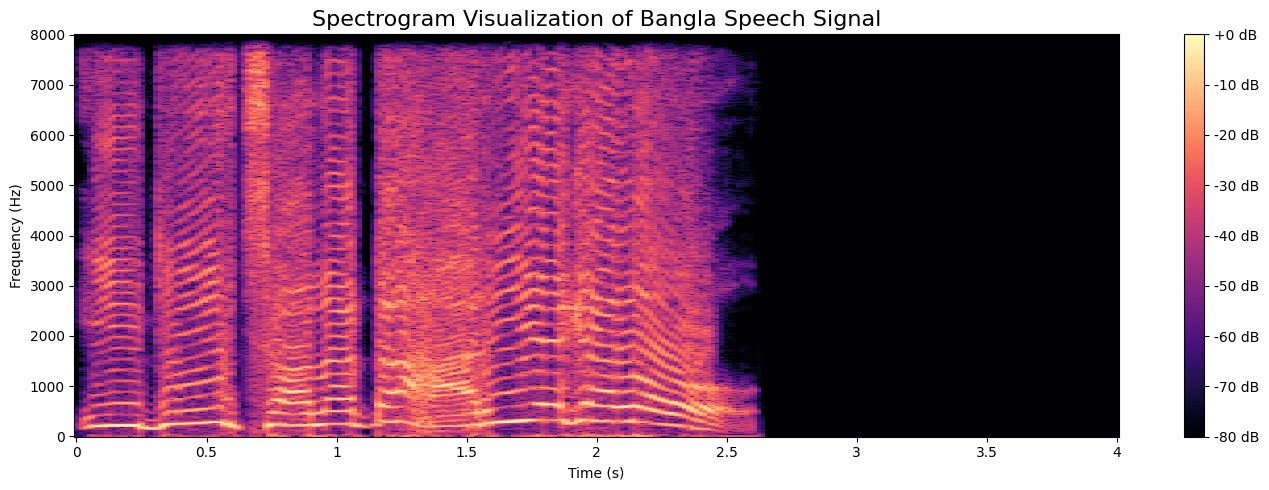

Spectrogram shape: (513, 251)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# give one audio file directly
sample_path = df.iloc[0]["filepath"]   # or: df[df["label"]=="Happy"].iloc[0]["filepath"]

SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
N_FFT = 1024
HOP_LENGTH = 256

# load + trim + pad/truncate
y, sr = librosa.load(sample_path, sr=SR)
y, _ = librosa.effects.trim(y, top_db=20)

if len(y) < SAMPLES:
    y = np.pad(y, (0, SAMPLES - len(y)))
else:
    y = y[:SAMPLES]

# STFT spectrogram
stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
spectrogram = np.abs(stft)
spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

# plot
plt.figure(figsize=(14, 5))
img = librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz",
    cmap="magma"
)

plt.title("Spectrogram Visualization of Bangla Speech Signal", fontsize=16)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(img, format="%+2.0f dB")
plt.tight_layout()
plt.show()

print("Spectrogram shape:", spectrogram_db.shape)

# 3-Channel Acoustic Feature Extraction for Bangla Speech Emotion Recognition

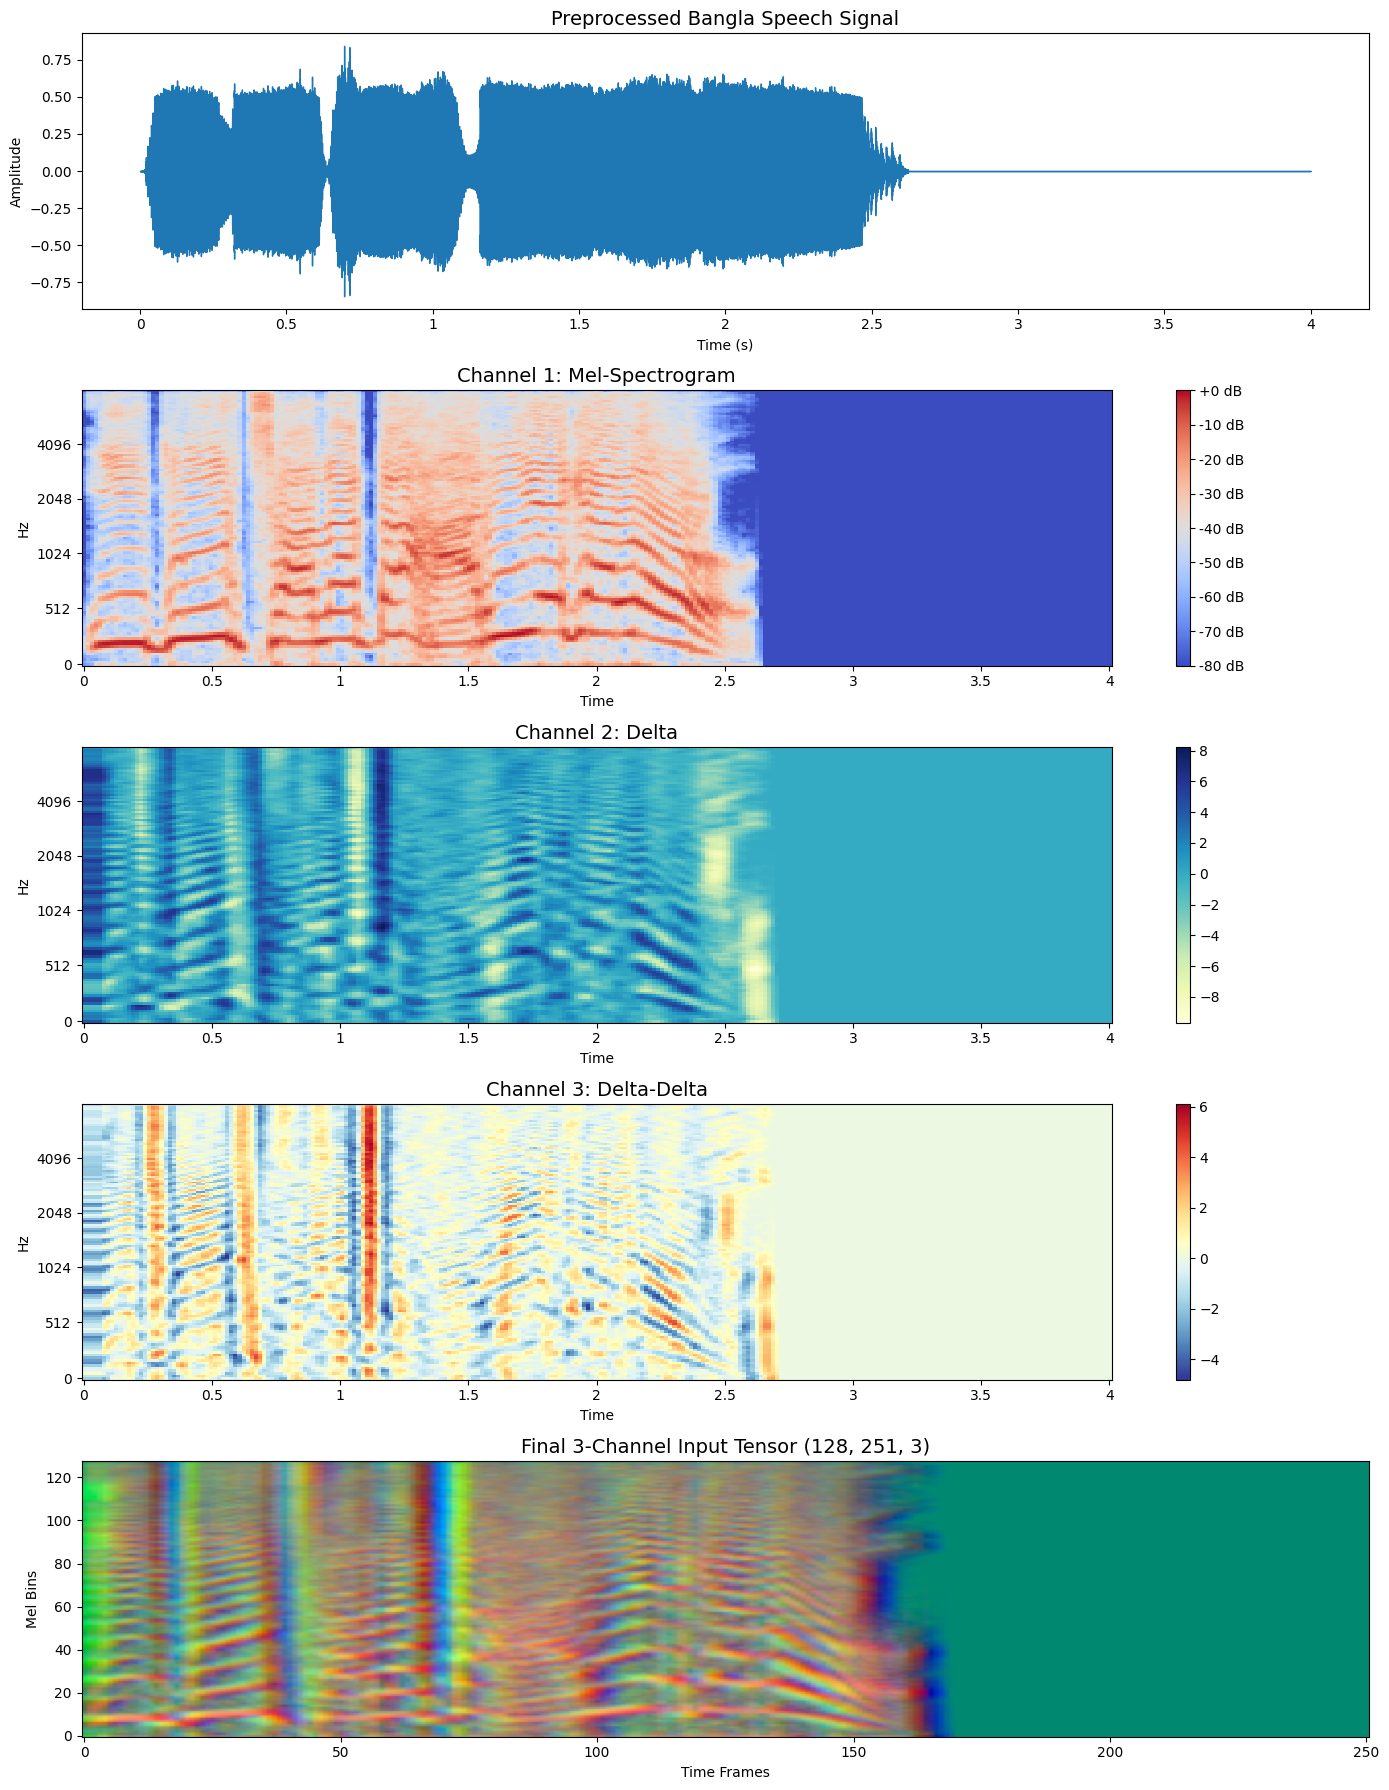

Final stacked tensor shape: (128, 251, 3)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# -----------------------------
# Choose one sample audio file
# -----------------------------
sample_path = df.iloc[0]["filepath"]   # or: df[df["label"]=="Happy"].iloc[0]["filepath"]

# -----------------------------
# Parameters
# -----------------------------
SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

# -----------------------------
# Load + preprocess audio
# -----------------------------
y, sr = librosa.load(sample_path, sr=SR)
y, _ = librosa.effects.trim(y, top_db=20)

if len(y) < SAMPLES:
    y = np.pad(y, (0, SAMPLES - len(y)))
else:
    y = y[:SAMPLES]

# -----------------------------
# Feature extraction
# -----------------------------
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)

mel_db = librosa.power_to_db(mel, ref=np.max)
delta = librosa.feature.delta(mel_db)
delta2 = librosa.feature.delta(mel_db, order=2)

# stack into 3-channel input
feature_3ch = np.stack([mel_db, delta, delta2], axis=-1)

# normalize for RGB-style visualization
feat_vis = feature_3ch.copy()
for c in range(3):
    ch = feat_vis[:, :, c]
    feat_vis[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title("Preprocessed Bangla Speech Signal", fontsize=14)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Mel spectrogram
img1 = librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    ax=axes[1],
    cmap="coolwarm"
)
axes[1].set_title("Channel 1: Mel-Spectrogram", fontsize=14)
fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

# Delta
img2 = librosa.display.specshow(
    delta,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    ax=axes[2],
    cmap="YlGnBu"
)
axes[2].set_title("Channel 2: Delta", fontsize=14)
fig.colorbar(img2, ax=axes[2])

# Delta-Delta
img3 = librosa.display.specshow(
    delta2,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    ax=axes[3],
    cmap="RdYlBu_r"
)
axes[3].set_title("Channel 3: Delta-Delta", fontsize=14)
fig.colorbar(img3, ax=axes[3])

# Final stacked 3-channel visualization
axes[4].imshow(feat_vis, aspect="auto", origin="lower")
axes[4].set_title(f"Final 3-Channel Input Tensor {feature_3ch.shape}", fontsize=14)
axes[4].set_xlabel("Time Frames")
axes[4].set_ylabel("Mel Bins")

plt.tight_layout()
plt.show()

print("Final stacked tensor shape:", feature_3ch.shape)

**Chromagram Visualization of Bangla Speech Signal**

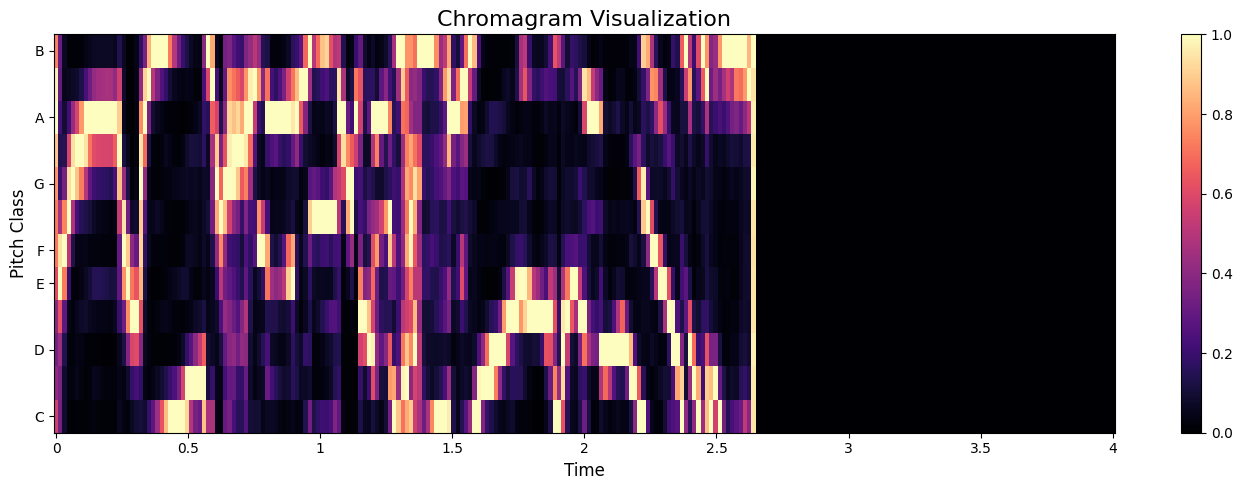

Chromagram shape: (12, 251)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# -----------------------------
# Choose one sample audio file
# -----------------------------
sample_path = df.iloc[0]["filepath"]   # or: df[df["label"]=="Happy"].iloc[0]["filepath"]

# -----------------------------
# Parameters
# -----------------------------
SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
N_FFT = 1024
HOP_LENGTH = 256

# -----------------------------
# Load + preprocess audio
# -----------------------------
y, sr = librosa.load(sample_path, sr=SR)
y, _ = librosa.effects.trim(y, top_db=20)

if len(y) < SAMPLES:
    y = np.pad(y, (0, SAMPLES - len(y)))
else:
    y = y[:SAMPLES]

# -----------------------------
# Chromagram extraction
# -----------------------------
chroma = librosa.feature.chroma_stft(
    y=y,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(14, 5))

img = librosa.display.specshow(
    chroma,
    x_axis="time",
    y_axis="chroma",
    sr=sr,
    hop_length=HOP_LENGTH,
    cmap="magma"
)

plt.title("Chromagram Visualization", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Pitch Class", fontsize=12)
plt.colorbar(img)
plt.tight_layout()
plt.show()

print("Chromagram shape:", chroma.shape)

**MFCC Visualization of Bangla Speech Signal**

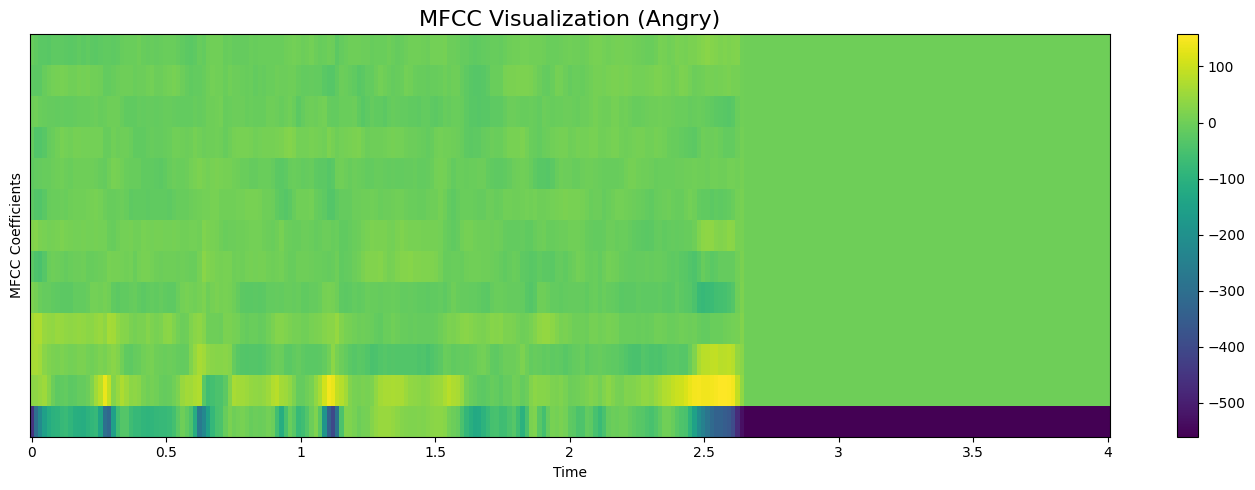

MFCC shape: (13, 251)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import os

# Use a file from the actual extracted dataset path
sample_path = df.iloc[0]["filepath"]

SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
N_MFCC = 13
N_FFT = 1024
HOP_LENGTH = 256

# load + trim + pad/truncate
try:
    y, sr = librosa.load(sample_path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    # extract MFCCs
    mfccs = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # plot
    plt.figure(figsize=(14, 5))
    img = librosa.display.specshow(
        mfccs,
        x_axis="time",
        sr=sr,
        hop_length=HOP_LENGTH,
        cmap="viridis"
    )

    plt.title(f"MFCC Visualization ({df.iloc[0]['label']})", fontsize=16)
    plt.xlabel("Time")
    plt.ylabel("MFCC Coefficients")
    plt.colorbar(img)
    plt.tight_layout()
    plt.show()

    print("MFCC shape:", mfccs.shape)
except Exception as e:
    print(f"Error loading file: {e}")

**Spectral Contrast Visualization of Bangla Speech Signal**

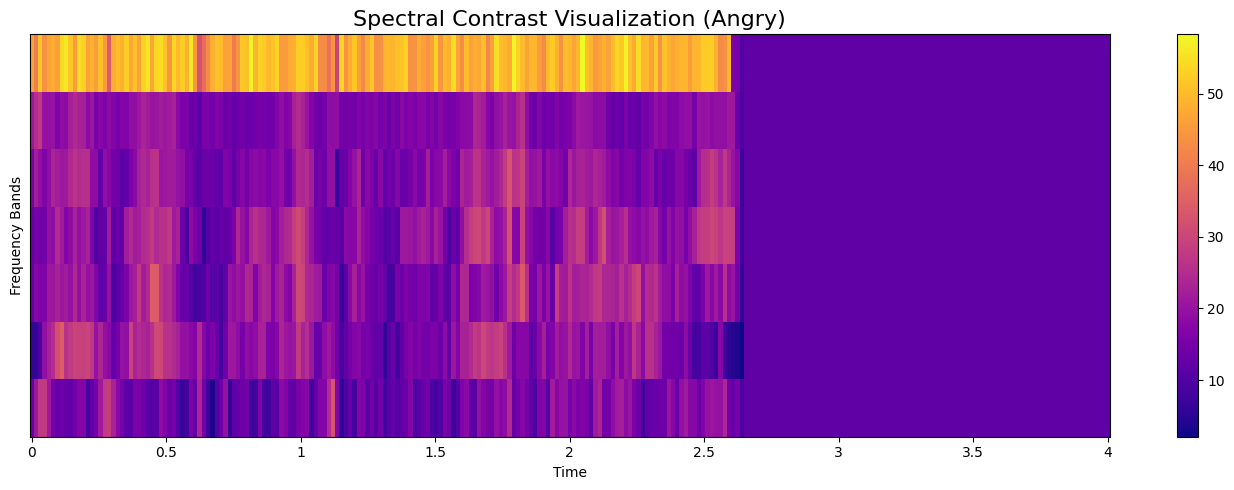

Spectral Contrast shape: (7, 251)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Use a valid path from the loaded dataset instead of a hardcoded path
sample_path = df.iloc[0]["filepath"]

SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
N_FFT = 1024
HOP_LENGTH = 256

try:
    # load + trim + pad/truncate
    y, sr = librosa.load(sample_path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    # extract spectral contrast
    spectral_contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # plot
    plt.figure(figsize=(14, 5))
    img = librosa.display.specshow(
        spectral_contrast,
        x_axis="time",
        sr=sr,
        hop_length=HOP_LENGTH,
        cmap="plasma"
    )

    plt.title(f"Spectral Contrast Visualization ({df.iloc[0]['label']})", fontsize=16)
    plt.xlabel("Time")
    plt.ylabel("Frequency Bands")
    plt.colorbar(img)
    plt.tight_layout()
    plt.show()

    print("Spectral Contrast shape:", spectral_contrast.shape)
except Exception as e:
    print(f"Error processing audio: {e}")

**Visualization of zero-crossing rate for an audio signal**

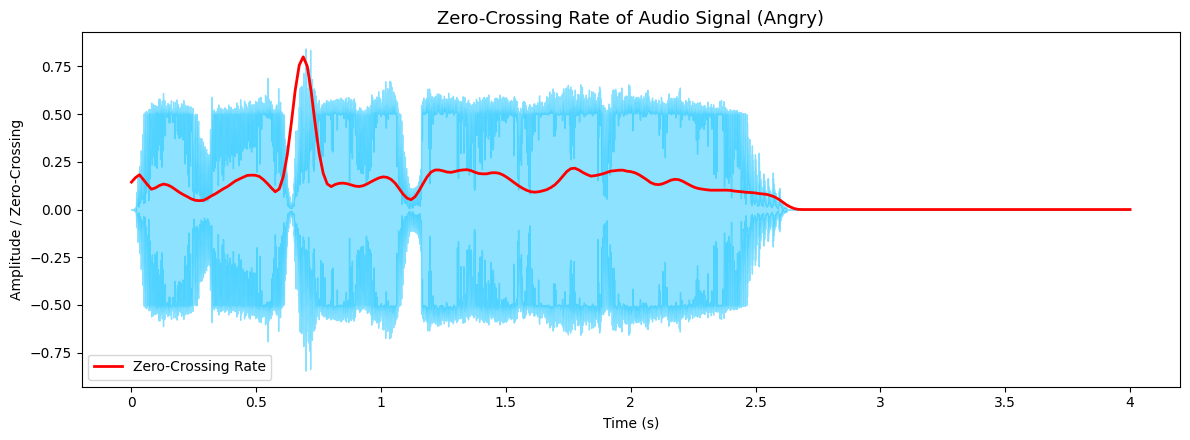

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Use a valid file from the loaded dataset
sample_path = df.iloc[0]["filepath"]

SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
FRAME_LENGTH = 1024
HOP_LENGTH = 256

try:
    y, sr = librosa.load(sample_path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )[0]

    zcr_times = librosa.times_like(zcr, sr=sr, hop_length=HOP_LENGTH)

    # simple moving average smoothing
    window = 5
    zcr_smooth = np.convolve(zcr, np.ones(window) / window, mode="same")

    # scale for visualization
    zcr_vis = zcr_smooth / (np.max(zcr_smooth) + 1e-8)
    zcr_vis = zcr_vis * 0.8

    plt.figure(figsize=(12, 4.5))
    librosa.display.waveshow(y, sr=sr, alpha=0.45, color="deepskyblue")
    plt.plot(zcr_times, zcr_vis, color="red", linewidth=2, label="Zero-Crossing Rate")

    plt.title(f"Zero-Crossing Rate of Audio Signal ({df.iloc[0]['label']})", fontsize=13)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude / Zero-Crossing")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error loading file: {e}")

**Time-Frequency Energy Distribution of Bangla Speech Signal**

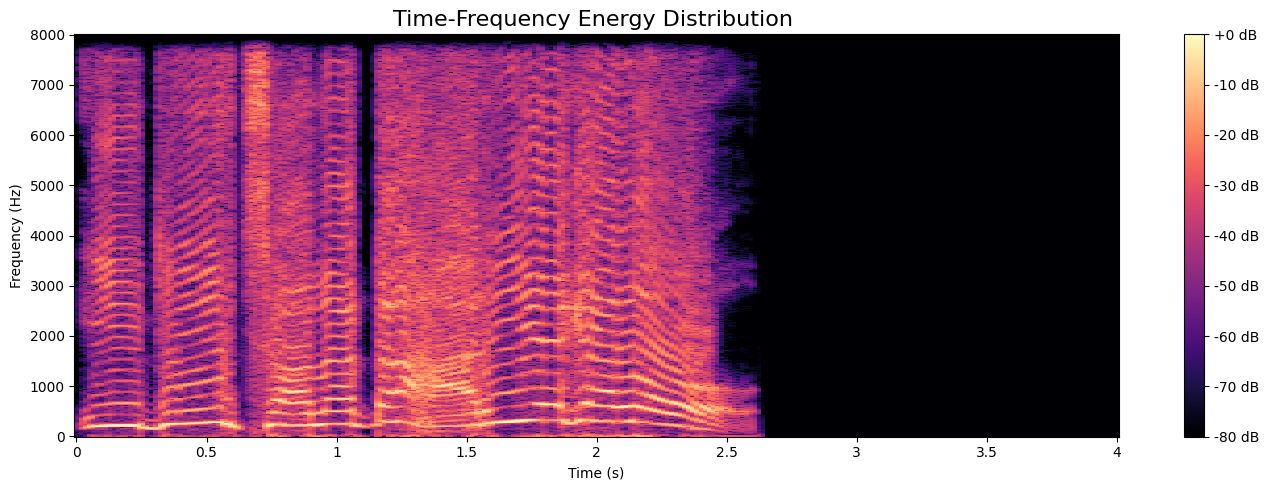

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Use a valid file path from the processed DataFrame
sample_path = df.iloc[0]["filepath"]

SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
N_FFT = 1024
HOP_LENGTH = 256

try:
    y, sr = librosa.load(sample_path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft) ** 2
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(14, 5))
    img = librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="hz",
        cmap="magma"
    )

    plt.title(f"Time-Frequency Energy Distribution ", fontsize=16)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(img, format="%+2.0f dB")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error loading audio file: {e}")

In [18]:
audio_extensions = [".wav", ".mp3", ".flac", ".ogg", ".m4a", ".mp4"]

rows = []

for folder_name in FOLDER_NAMES:
    class_dir = os.path.join(DATASET_DIR, folder_name)

    if not os.path.isdir(class_dir):
        print("Missing folder:", class_dir)
        continue

    final_label = FOLDER_TO_LABEL[folder_name]

    for root, _, files in os.walk(class_dir):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in audio_extensions:
                rows.append({
                    "filepath": os.path.join(root, file),
                    "folder_name": folder_name,
                    "label": final_label,
                    "label_id": label_to_idx[final_label]
                })

df = pd.DataFrame(rows)

print("Total files:", len(df))
print(df["label"].value_counts())
df.head()

Total files: 7000
label
Angry        1000
Disgusted    1000
Fearful      1000
Happy        1000
Neutral      1000
Sad          1000
Surprised    1000
Name: count, dtype: int64


,filepath,folder_name,label,label_id
0,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
1,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
2,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
3,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0
4,/content/Bangla_Emotion_Dataset/archive 1/arch...,Angry,Angry,0


In [19]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/14fhYZiAMYunx__OY2grwETkv_BcF2WOM_peZwUFvSMI/edit#gid=0


In [20]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 5600
Val: 700
Test: 700


In [21]:
def load_audio(file_path, sr=SR, target_len=SAMPLES):
    try:
        y, _ = librosa.load(file_path, sr=sr)
    except Exception as e:
        print(f"Warning: failed to load {file_path}: {e}")
        return np.zeros(target_len, dtype=np.float32)

    if y is None or len(y) == 0:
        return np.zeros(target_len, dtype=np.float32)

    # trim silence
    y, _ = librosa.effects.trim(y, top_db=20)

    # pad or cut
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    return y.astype(np.float32)


def add_noise(y, noise_factor=0.003):
    noise = np.random.randn(len(y))
    y = y + noise_factor * noise
    return y.astype(np.float32)


def time_shift(y, shift_max=0.08):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    if shift == 0:
        return y.astype(np.float32)

    y_shifted = np.zeros_like(y)

    if shift > 0:
        y_shifted[shift:] = y[:-shift]
    else:
        y_shifted[:shift] = y[-shift:]

    return y_shifted.astype(np.float32)


def pitch_shift_audio(y, sr=SR):
    n_steps = np.random.choice([-2, -1, 1, 2])
    y = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)
    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]
    return y.astype(np.float32)


def time_stretch_audio(y):
    rate = np.random.uniform(0.9, 1.1)
    y2 = librosa.effects.time_stretch(y, rate=rate)
    if len(y2) < SAMPLES:
        y2 = np.pad(y2, (0, SAMPLES - len(y2)))
    else:
        y2 = y2[:SAMPLES]
    return y2.astype(np.float32)


def apply_augmentation(y):
    y_aug = y.copy()

    if np.random.rand() < 0.30:
        y_aug = add_noise(y_aug)
    if np.random.rand() < 0.30:
        y_aug = time_shift(y_aug)
    if np.random.rand() < 0.20:
        y_aug = pitch_shift_audio(y_aug)
    if np.random.rand() < 0.20:
        y_aug = time_stretch_audio(y_aug)

    return y_aug.astype(np.float32)


def audio_to_feature3(y, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # normalize mel
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    delta1 = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

    # normalize deltas
    delta1 = (delta1 - delta1.min()) / (delta1.max() - delta1.min() + 1e-8)
    delta2 = (delta2 - delta2.min()) / (delta2.max() - delta2.min() + 1e-8)

    feat = np.stack([mel_db, delta1, delta2], axis=-1)  # (n_mels, time, 3)
    return feat.astype(np.float32)

In [22]:
import math

In [23]:
# Smaller batch size helps memory
BATCH_SIZE = 32

# Check one sample shape
sample_audio = load_audio(train_df.iloc[0]["filepath"])
sample_feat = audio_to_feature3(sample_audio)

INPUT_SHAPE = sample_feat.shape
print("Input shape:", INPUT_SHAPE)   # example: (128, 251, 3)

Input shape: (128, 251, 3)


In [24]:
class AudioSequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=16, augment=False, shuffle=True):
        self.df = dataframe.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        X_batch = []
        y_batch = []

        for i in batch_indices:
            row = self.df.iloc[i]

            audio = load_audio(row["filepath"])

            if self.augment:
                audio = apply_augmentation(audio)

            feat = audio_to_feature3(audio)

            X_batch.append(feat)
            y_batch.append(row["label_id"])

        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = np.array(y_batch, dtype=np.int32)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [25]:
train_gen = AudioSequence(train_df, batch_size=BATCH_SIZE, augment=True, shuffle=True)
val_gen   = AudioSequence(val_df,   batch_size=BATCH_SIZE, augment=False, shuffle=False)
test_gen  = AudioSequence(test_df,  batch_size=BATCH_SIZE, augment=False, shuffle=False)

print("Train batches:", len(train_gen))
print("Val batches:", len(val_gen))
print("Test batches:", len(test_gen))

Train batches: 175
Val batches: 22
Test batches: 22


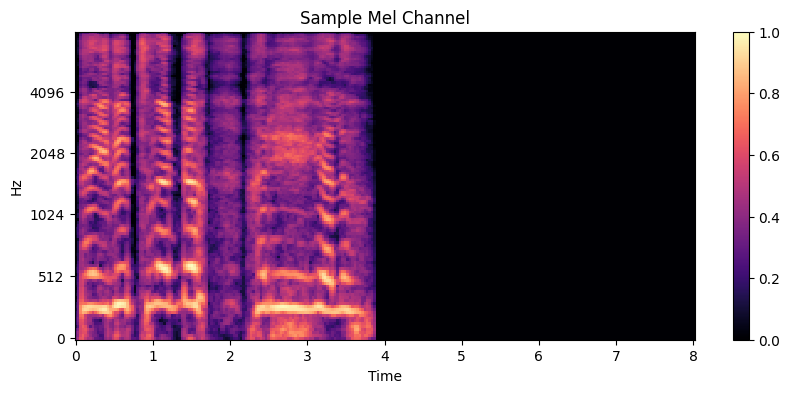

In [26]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(sample_feat[:, :, 0], sr=SR, x_axis="time", y_axis="mel")
plt.title("Sample Mel Channel")
plt.colorbar()
plt.show()

In [27]:
classes = np.unique(train_df["label_id"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"]
)

class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Computed class weights:", class_weight)

# For a perfectly balanced dataset these will all be 1.0, which is fine.

Computed class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}


In [28]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        return x + self.pos_emb(positions)

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_len": self.max_len,
            "d_model": self.d_model
        })
        return config


class TransformerEncoder(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.2, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout

        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )

        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(d_model),
        ])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_output = self.att(x, x)
        attn_output = self.drop1(attn_output, training=training)
        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x, training=training)
        ffn_output = self.drop2(ffn_output, training=training)
        return self.norm2(x + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout_rate
        })
        return config

In [29]:
def build_cnn_transformer(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(192, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    freq_dim = x.shape[1]
    time_dim = x.shape[2]
    ch_dim = x.shape[3]

    x = layers.Permute((2, 1, 3))(x)
    x = layers.Reshape((time_dim, freq_dim * ch_dim))(x)

    d_model = 128
    x = layers.Dense(d_model)(x)
    x = PositionalEmbedding(max_len=512, d_model=d_model)(x)

    x = TransformerEncoder(d_model=128, num_heads=4, ff_dim=256, dropout=0.2)(x)
    x = TransformerEncoder(d_model=128, num_heads=4, ff_dim=256, dropout=0.2)(x)

    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)

In [30]:
model = build_cnn_transformer(
    input_shape=INPUT_SHAPE,
    num_classes=len(LABELS)
)

In [31]:
try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    )
except:
    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 251,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 251,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 251,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 125,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 125,   │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 125,   │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 125,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 62,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 62,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 62,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 62,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 31,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 31,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 31,    │    221,376 │ dropout_2[0][0]   │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 31,    │        768 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 15,     │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 15,     │          0 │ max_pooling2d_3[

 Total params: 877,319 (3.35 MB)

 Trainable params: 876,487 (3.34 MB)

 Non-trainable params: 832 (3.25 KB)

In [32]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True
    )
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.2420 - loss: 1.8727 - val_accuracy: 0.1429 - val_loss: 3.5511 - learning_rate: 3.0000e-04
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.3255 - loss: 1.6353 - val_accuracy: 0.1971 - val_loss: 3.2427 - learning_rate: 3.0000e-04
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.4239 - loss: 1.4550 - val_accuracy: 0.2543 - val_loss: 2.4200 - learning_rate: 3.0000e-04
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.4786 - loss: 1.3400 - val_accuracy: 0.5571 - val_loss: 1.1280 - learning_rate: 3.0000e-04
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.5054 - loss: 1.2640 - val_accuracy: 0.5586 - val_loss: 1.1716 - learning_rate: 3.0000e-04
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.5391 - loss: 1.1900 - val_accuracy: 0.6157 - val_loss: 0.9671 - learning_rate: 3.0000e-04
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - acc

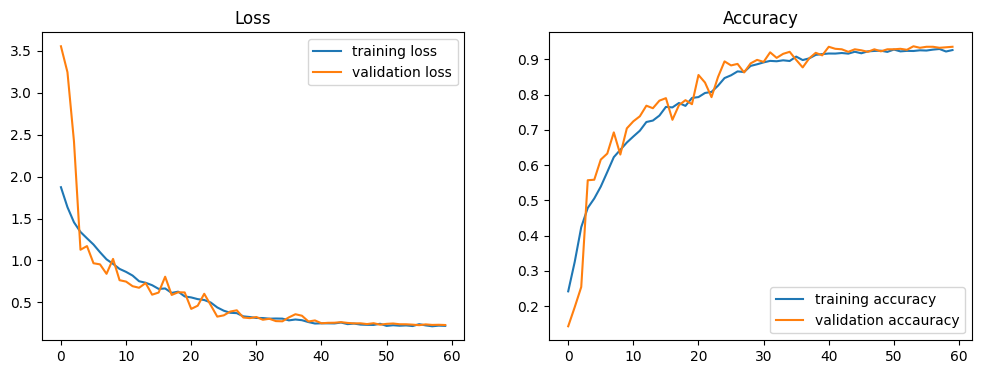

In [33]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="training accuracy")
plt.plot(history.history["val_accuracy"], label="validation accauracy")
plt.legend()
plt.title("Accuracy")

plt.show()

In [34]:
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "PositionalEmbedding": PositionalEmbedding,
        "TransformerEncoder": TransformerEncoder,
    },
    compile=False,
    safe_mode=False,
)

best_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Loaded best model from:", BEST_MODEL_PATH)

Loaded best model from: /content/bangla_cnn_transformer_best.keras


In [35]:
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 739ms/step - accuracy: 0.9257 - loss: 0.1883
Test Loss: 0.18828700482845306
Test Accuracy: 0.9257143139839172


In [36]:
y_prob = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

y_true = test_df["label_id"].to_numpy()

print(classification_report(y_true, y_pred, target_names=LABELS))

22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 684ms/step
              precision    recall  f1-score   support

       Angry       0.89      0.95      0.92       100
       Happy       0.92      0.92      0.92       100
     Neutral       0.96      0.99      0.98       100
         Sad       0.93      0.94      0.94       100
   Disgusted       0.87      0.82      0.85       100
     Fearful       0.98      0.93      0.95       100
   Surprised       0.93      0.93      0.93       100

    accuracy                           0.93       700
   macro avg       0.93      0.93      0.93       700
weighted avg       0.93      0.93      0.93       700



22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 556ms/step


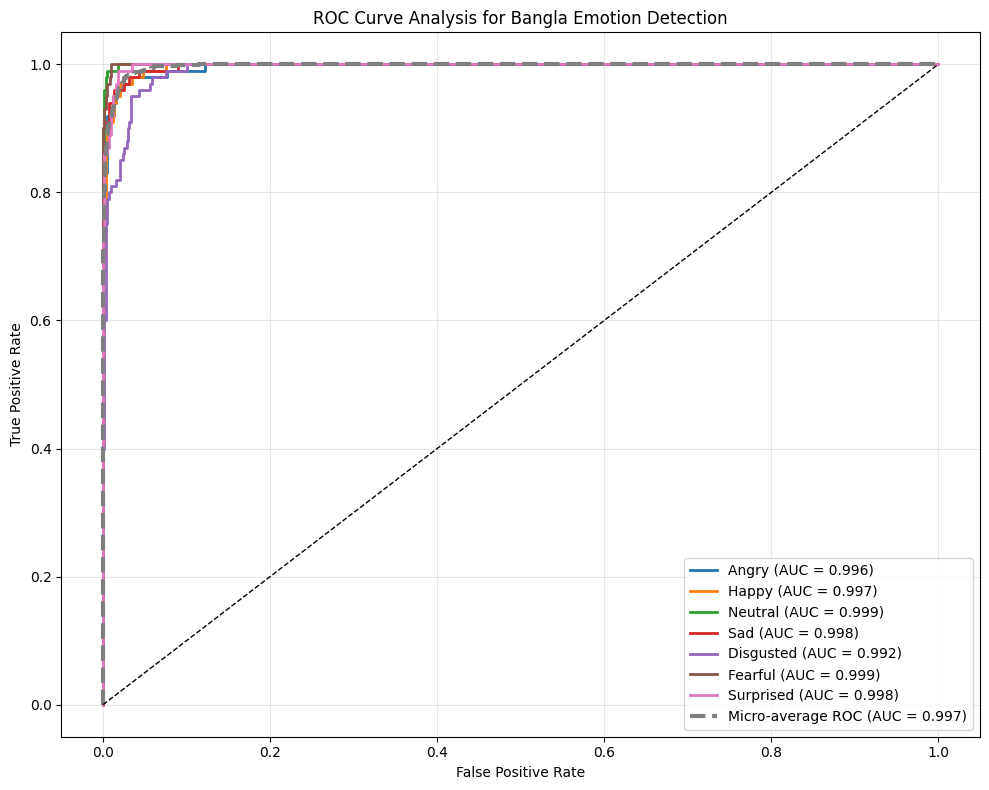

In [43]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Predict probabilities using the correct generator name: test_gen
y_prob = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# Use the correct dataframe name: test_df
y_true = test_df["label_id"].to_numpy()

# Labels
n_classes = len(LABELS)

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# ROC computation
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{LABELS[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    linewidth=3,
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})"
)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Analysis for Bangla Emotion Detection")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

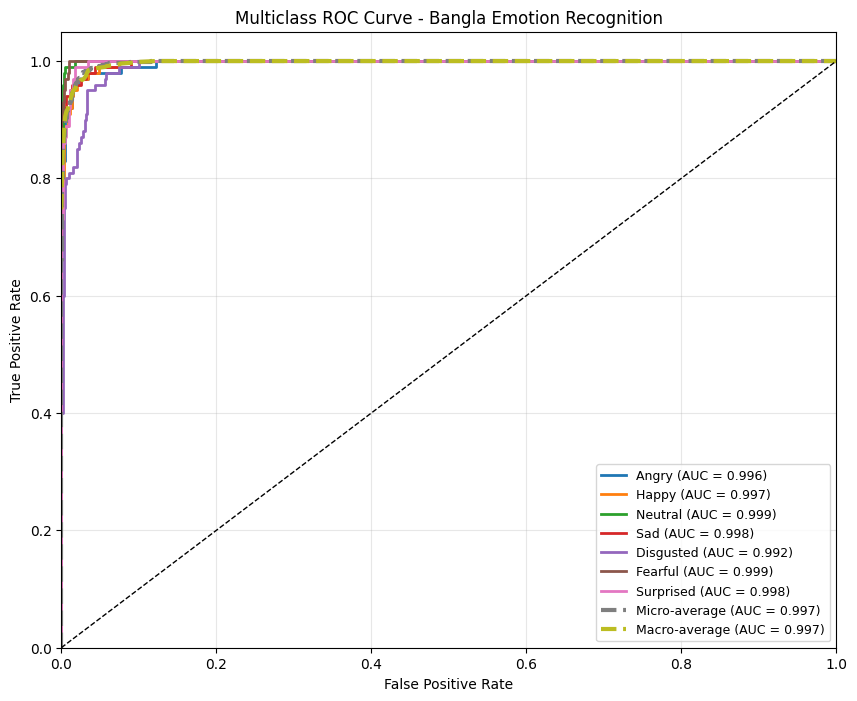

Micro-average AUC: 0.9973
Macro-average AUC: 0.9973
Angry: 0.9963
Happy: 0.9968
Neutral: 0.9995
Sad: 0.9976
Disgusted: 0.9917
Fearful: 0.9995
Surprised: 0.9979


In [42]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Assumes these already exist from your notebook:
# y_prob   = best_model.predict(test_gen, verbose=1)
# y_true   = test_df["label_id"].to_numpy()
# LABELS   = ["Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad", "Surprised"]  # or your existing LABELS list

n_classes = len(LABELS)
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}

# Per-class ROC
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot
plt.figure(figsize=(10, 8))

for i, label in enumerate(LABELS):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{label} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["micro"], tpr["micro"], linestyle="--", lw=3, label=f"Micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], linestyle="--", lw=3, label=f"Macro-average (AUC = {roc_auc['macro']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Bangla Emotion Recognition")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.show()

print("Micro-average AUC:", round(roc_auc["micro"], 4))
print("Macro-average AUC:", round(roc_auc["macro"], 4))
for i, label in enumerate(LABELS):
    print(f"{label}: {roc_auc[i]:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 538ms/step

Class-wise Validation Accuracy:

    Class  Correct  Total  Validation Accuracy (%)
    Angry       96    100                     96.0
    Happy       94    100                     94.0
  Neutral       98    100                     98.0
      Sad       96    100                     96.0
Disgusted       86    100                     86.0
  Fearful       90    100                     90.0
Surprised       95    100                     95.0

Overall Validation Accuracy: 93.57%


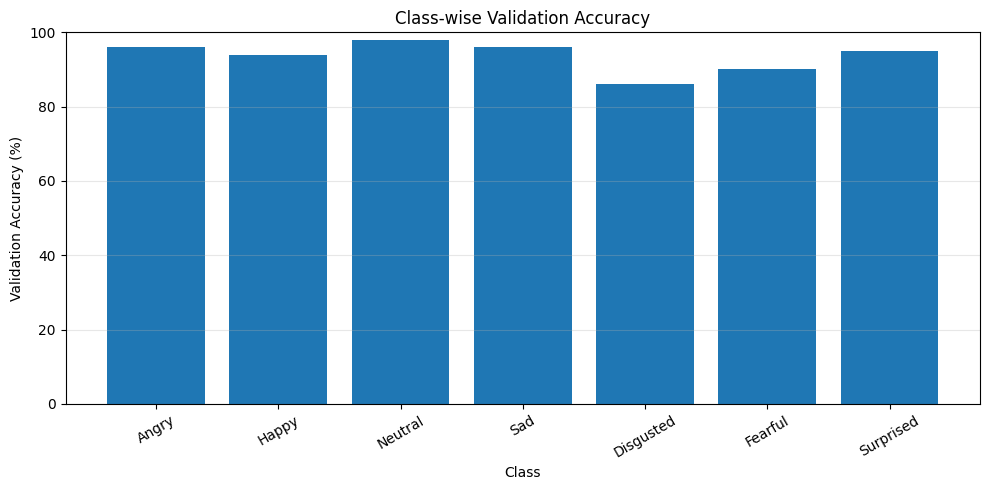

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Reset index to ensure alignment
val_df_fixed = val_df.reset_index(drop=True)

# Rebuild validation generator using the correct class name 'AudioSequence'
val_eval_gen = AudioSequence(
    val_df_fixed,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

# True labels and predictions
y_val_true = val_df_fixed["label_id"].to_numpy()
y_val_prob = best_model.predict(val_eval_gen, verbose=1)
y_val_pred = np.argmax(y_val_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred, labels=np.arange(len(LABELS)))

# Class-wise accuracy = correct predictions for class / total samples of class
class_totals = cm.sum(axis=1)
class_correct = np.diag(cm)
class_acc = np.divide(class_correct, class_totals, out=np.zeros_like(class_correct, dtype=float), where=class_totals != 0)

# Table
class_acc_df = pd.DataFrame({
    "Class": LABELS,
    "Correct": class_correct,
    "Total": class_totals,
    "Validation Accuracy": class_acc
})

class_acc_df["Validation Accuracy (%)"] = (class_acc_df["Validation Accuracy"] * 100).round(2)

print("\nClass-wise Validation Accuracy:\n")
print(class_acc_df[["Class", "Correct", "Total", "Validation Accuracy (%)"]].to_string(index=False))

overall_val_acc = (class_correct.sum() / class_totals.sum()) * 100
print(f"\nOverall Validation Accuracy: {overall_val_acc:.2f}%")

# Plot
plt.figure(figsize=(10, 5))
plt.bar(class_acc_df["Class"], class_acc_df["Validation Accuracy (%)"])
plt.ylabel("Validation Accuracy (%)")
plt.xlabel("Class")
plt.title("Class-wise Validation Accuracy")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 584ms/step

Table: Class-wise accuracy of proposed model for validation dataset.

Class No Class Title Accuracy (%)
 Class 0       ANGRY        96.00
 Class 1       HAPPY        94.00
 Class 2     NEUTRAL        98.00
 Class 3         SAD        96.00
 Class 4   DISGUSTED        86.00
 Class 5     FEARFUL        90.00
 Class 6   SURPRISED        95.00


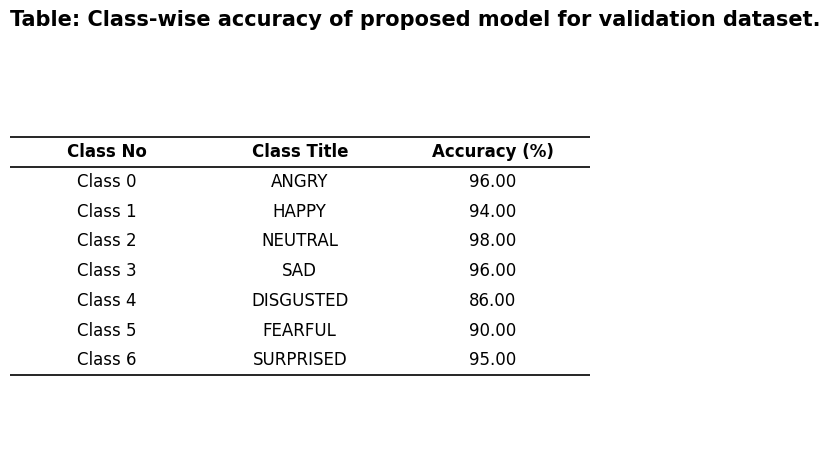

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Make sure order is fixed
val_df_eval = val_df.reset_index(drop=True)

# Validation generator without shuffle - renamed to AudioSequence to match your definition
val_eval_gen = AudioSequence(
    val_df_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

# True labels and predictions
y_val_true = val_df_eval["label_id"].to_numpy()
y_val_prob = best_model.predict(val_eval_gen, verbose=1)
y_val_pred = np.argmax(y_val_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred, labels=np.arange(len(LABELS)))

# Class-wise accuracy
class_totals = cm.sum(axis=1)
class_correct = np.diag(cm)
class_acc = np.divide(
    class_correct,
    class_totals,
    out=np.zeros_like(class_correct, dtype=float),
    where=class_totals != 0
) * 100

# Create table
table_df = pd.DataFrame({
    "Class No": [f"Class {i}" for i in range(len(LABELS))],
    "Class Title": [label.upper() for label in LABELS],
    "Accuracy (%)": [f"{acc:.2f}" for acc in class_acc]
})

# Print plain table
print("\nTable: Class-wise accuracy of proposed model for validation dataset.\n")
print(table_df.to_string(index=False))

# Display styled table like paper format
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.axis("off")

title = "Table: Class-wise accuracy of proposed model for validation dataset."
ax.text(
    0.0, 1.05, title,
    fontsize=15, fontweight="bold",
    ha="left", va="bottom",
    transform=ax.transAxes
)

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 1.6)

# Style borders to resemble paper table
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.visible_edges = "TB"
        cell.set_linewidth(1.2)
    else:
        cell.visible_edges = ""
        cell.set_linewidth(0.8)

# Bottom border on last row
last_row = len(table_df)
for col in range(len(table_df.columns)):
    tbl[(last_row, col)].visible_edges = "B"
    tbl[(last_row, col)].set_linewidth(1.2)

plt.tight_layout()
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 698ms/step

Table: Class-wise accuracy of proposed model for test dataset.

Class No Class Title Accuracy (%)
 Class 0       ANGRY        95.00
 Class 1       HAPPY        92.00
 Class 2     NEUTRAL        99.00
 Class 3         SAD        94.00
 Class 4   DISGUSTED        82.00
 Class 5     FEARFUL        93.00
 Class 6   SURPRISED        93.00


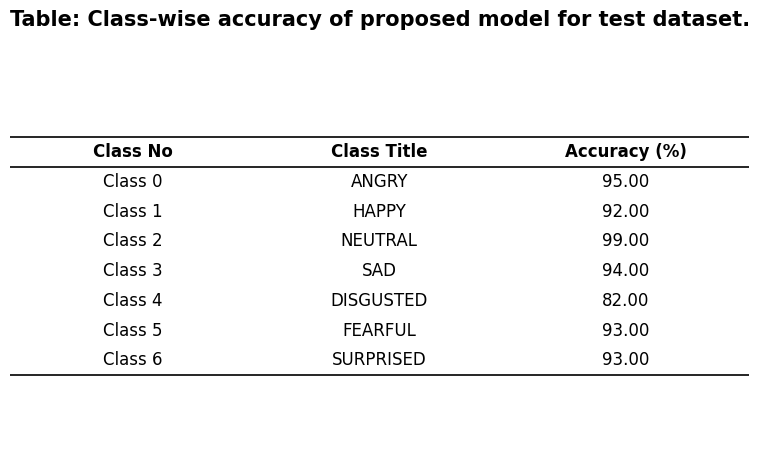

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Make sure order is fixed
test_df_eval = test_df.reset_index(drop=True)

# Test generator without shuffle - Fixed: changed AudioGenerator to AudioSequence
test_eval_gen = AudioSequence(
    test_df_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

# True labels and predictions
y_test_true = test_df_eval["label_id"].to_numpy()
y_test_prob = best_model.predict(test_eval_gen, verbose=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred, labels=np.arange(len(LABELS)))

# Class-wise accuracy
class_totals = cm.sum(axis=1)
class_correct = np.diag(cm)
class_acc = np.divide(
    class_correct,
    class_totals,
    out=np.zeros_like(class_correct, dtype=float),
    where=class_totals != 0
) * 100

# Create paper-style table dataframe
table_df = pd.DataFrame({
    "Class No": [f"Class {i}" for i in range(len(LABELS))],
    "Class Title": [label.upper() for label in LABELS],
    "Accuracy (%)": [f"{acc:.2f}" for acc in class_acc]
})

# Print plain text version
print("\nTable: Class-wise accuracy of proposed model for test dataset.\n")
print(table_df.to_string(index=False))

# Draw styled table like paper format
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.axis("off")

title = "Table: Class-wise accuracy of proposed model for test dataset."
ax.text(
    0.0, 1.05, title,
    fontsize=15, fontweight="bold",
    ha="left", va="bottom",
    transform=ax.transAxes
)

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 1.6)

# Style borders to resemble journal/paper table
nrows = len(table_df) + 1
ncols = len(table_df.columns)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_facecolor("white")
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.visible_edges = "TB"
        cell.set_linewidth(1.2)
    else:
        cell.visible_edges = ""
        cell.set_linewidth(0.8)

# Bottom border on last row
last_row = len(table_df)
for col in range(ncols):
    tbl[(last_row, col)].visible_edges = "B"
    tbl[(last_row, col)].set_linewidth(1.2)

plt.tight_layout()
plt.show()

**K-Fold Cross Validation**

In [50]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pandas as pd
import tensorflow as tf
import gc

# =========================
# K-Fold settings
# =========================
N_SPLITS = 5
INNER_VAL_SIZE = 0.10   # small validation split from training folds for early stopping
EPOCHS_CV = EPOCHS      # uses your existing EPOCHS
BATCH_SIZE_CV = BATCH_SIZE

# =========================
# Prepare full dataset
# =========================
df_cv = df.reset_index(drop=True).copy()
y_all = df_cv["label_id"].to_numpy()

# Compute input shape directly from one sample
sample_audio = load_audio(df_cv.iloc[0]["filepath"])
sample_feat = audio_to_feature3(sample_audio)
INPUT_SHAPE_CV = sample_feat.shape

print("Input shape for CV:", INPUT_SHAPE_CV)
print("Total samples:", len(df_cv))
print("Classes:", LABELS)

# =========================
# Cross-validation containers
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []
oof_pred = np.full(len(df_cv), -1, dtype=int)
oof_prob = np.zeros((len(df_cv), len(LABELS)), dtype=np.float32)

# =========================
# Run folds
# =========================
for fold, (train_val_idx, test_idx) in enumerate(skf.split(df_cv, y_all), start=1):
    print(f"\n{'='*60}")
    print(f"Fold {fold}/{N_SPLITS}")
    print(f"{'='*60}")

    # Split into train+val and fold-test
    train_val_df = df_cv.iloc[train_val_idx].reset_index(drop=True)
    fold_test_df = df_cv.iloc[test_idx].reset_index(drop=True)

    # Inner validation split for callbacks
    fold_train_df, fold_val_df = train_test_split(
        train_val_df,
        test_size=INNER_VAL_SIZE,
        stratify=train_val_df["label_id"],
        random_state=SEED + fold
    )

    print("Train:", len(fold_train_df), "| Val:", len(fold_val_df), "| Test:", len(fold_test_df))

    # Generators
    fold_train_gen = AudioSequence(fold_train_df, batch_size=BATCH_SIZE_CV, augment=True, shuffle=True)
    fold_val_gen   = AudioSequence(fold_val_df,   batch_size=BATCH_SIZE_CV, augment=False, shuffle=False)
    fold_test_gen  = AudioSequence(fold_test_df,  batch_size=BATCH_SIZE_CV, augment=False, shuffle=False)

    # Clear previous model
    tf.keras.backend.clear_session()
    gc.collect()

    # Build model
    model_cv = build_cnn_transformer(
        input_shape=INPUT_SHAPE_CV,
        num_classes=len(LABELS)
    )

    # Optimizer
    try:
        optimizer_cv = tf.keras.optimizers.AdamW(
            learning_rate=3e-4,
            weight_decay=1e-4
        )
    except AttributeError:
        optimizer_cv = tf.keras.optimizers.Adam(learning_rate=3e-4)

    model_cv.compile(
        optimizer=optimizer_cv,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Class weights
    fold_classes = np.unique(fold_train_df["label_id"])
    fold_weights = compute_class_weight(
        class_weight="balanced",
        classes=fold_classes,
        y=fold_train_df["label_id"]
    )
    class_weight_cv = {int(c): float(w) for c, w in zip(fold_classes, fold_weights)}

    # Callbacks
    callbacks_cv = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
    ]

    # Train
    history_cv = model_cv.fit(
        fold_train_gen,
        validation_data=fold_val_gen,
        epochs=EPOCHS_CV,
        callbacks=callbacks_cv,
        class_weight=class_weight_cv,
        verbose=1
    )

    # Evaluate on held-out fold
    fold_loss, fold_acc = model_cv.evaluate(fold_test_gen, verbose=0)
    fold_prob = model_cv.predict(fold_test_gen, verbose=0)
    fold_pred = np.argmax(fold_prob, axis=1)
    fold_true = fold_test_df["label_id"].to_numpy()

    # Save OOF predictions
    oof_prob[test_idx] = fold_prob
    oof_pred[test_idx] = fold_pred

    # Fold stats
    best_val_acc = max(history_cv.history["val_accuracy"])
    best_val_loss = min(history_cv.history["val_loss"])
    epochs_ran = len(history_cv.history["loss"])

    fold_results.append({
        "Fold": fold,
        "Train Samples": len(fold_train_df),
        "Val Samples": len(fold_val_df),
        "Test Samples": len(fold_test_df),
        "Best Val Accuracy (%)": round(best_val_acc * 100, 2),
        "Best Val Loss": round(best_val_loss, 4),
        "Fold Test Accuracy (%)": round(fold_acc * 100, 2),
        "Fold Test Loss": round(fold_loss, 4),
        "Epochs Ran": epochs_ran
    })

    print(f"Fold {fold} Test Accuracy: {fold_acc * 100:.2f}%")

# =========================
# Fold-wise summary
# =========================
results_df = pd.DataFrame(fold_results)

print("\n" + "="*60)
print("K-FOLD CROSS VALIDATION RESULTS")
print("="*60)
print(results_df.to_string(index=False))

mean_acc = results_df["Fold Test Accuracy (%)"].mean()
std_acc = results_df["Fold Test Accuracy (%)"].std()
mean_val_acc = results_df["Best Val Accuracy (%)"].mean()

print(f"\nMean Fold Test Accuracy: {mean_acc:.2f}%")
print(f"Std Fold Test Accuracy : {std_acc:.2f}")
print(f"Mean Best Val Accuracy : {mean_val_acc:.2f}%")

# =========================
# Overall OOF accuracy
# =========================
overall_oof_acc = accuracy_score(y_all, oof_pred) * 100
print(f"\nOverall Out-of-Fold Accuracy: {overall_oof_acc:.2f}%")

# =========================
# Class-wise CV accuracy from OOF predictions
# =========================
cm = confusion_matrix(y_all, oof_pred, labels=np.arange(len(LABELS)))
class_totals = cm.sum(axis=1)
class_correct = np.diag(cm)
class_acc = np.divide(
    class_correct,
    class_totals,
    out=np.zeros_like(class_correct, dtype=float),
    where=class_totals != 0
) * 100

classwise_cv_df = pd.DataFrame({
    "Class No": [f"Class {i}" for i in range(len(LABELS))],
    "Class Title": [label.upper() for label in LABELS],
    "CV Accuracy (%)": [f"{acc:.2f}" for acc in class_acc]
})

print("\nClass-wise K-Fold CV Accuracy:\n")
print(classwise_cv_df.to_string(index=False))

Input shape for CV: (128, 251, 3)
Total samples: 7000
Classes: ['Angry', 'Happy', 'Neutral', 'Sad', 'Disgusted', 'Fearful', 'Surprised']

Fold 1/5
Train: 5040 | Val: 560 | Test: 1400
Epoch 1/60
 42/158 ━━━━━━━━━━━━━━━━━━━━ 2:04 1s/step - accuracy: 0.1418 - loss: 2.5374

KeyboardInterrupt: 

**Layer parameters of the proposed CNN-Transformer model for Bangla speech emotion recognition.**


Table 1: Layer parameters of proposed CNN-Transformer model.

                 Layer      Filters/Units   Output Shape Kernel Size Stride
         Convolution 1                 32 128 × 251 × 32       3 × 3  1 × 1
         Max-pooling 1                  -  64 × 125 × 32       2 × 2  2 × 2
         Dropout (15%)                  -  64 × 125 × 32           -      -
         Convolution 2                 64  64 × 125 × 64       3 × 3  1 × 1
         Max-pooling 2                  -   32 × 62 × 64       2 × 2  2 × 2
         Dropout (20%)                  -   32 × 62 × 64           -      -
         Convolution 3                128  32 × 62 × 128       3 × 3  1 × 1
         Max-pooling 3                  -  16 × 31 × 128       2 × 2  2 × 2
         Dropout (25%)                  -  16 × 31 × 128           -      -
         Convolution 4                192  16 × 31 × 192       3 × 3  1 × 1
         Max-pooling 4                  -   8 × 15 × 192       2 × 2  2 × 2
         Dropout (25%)   

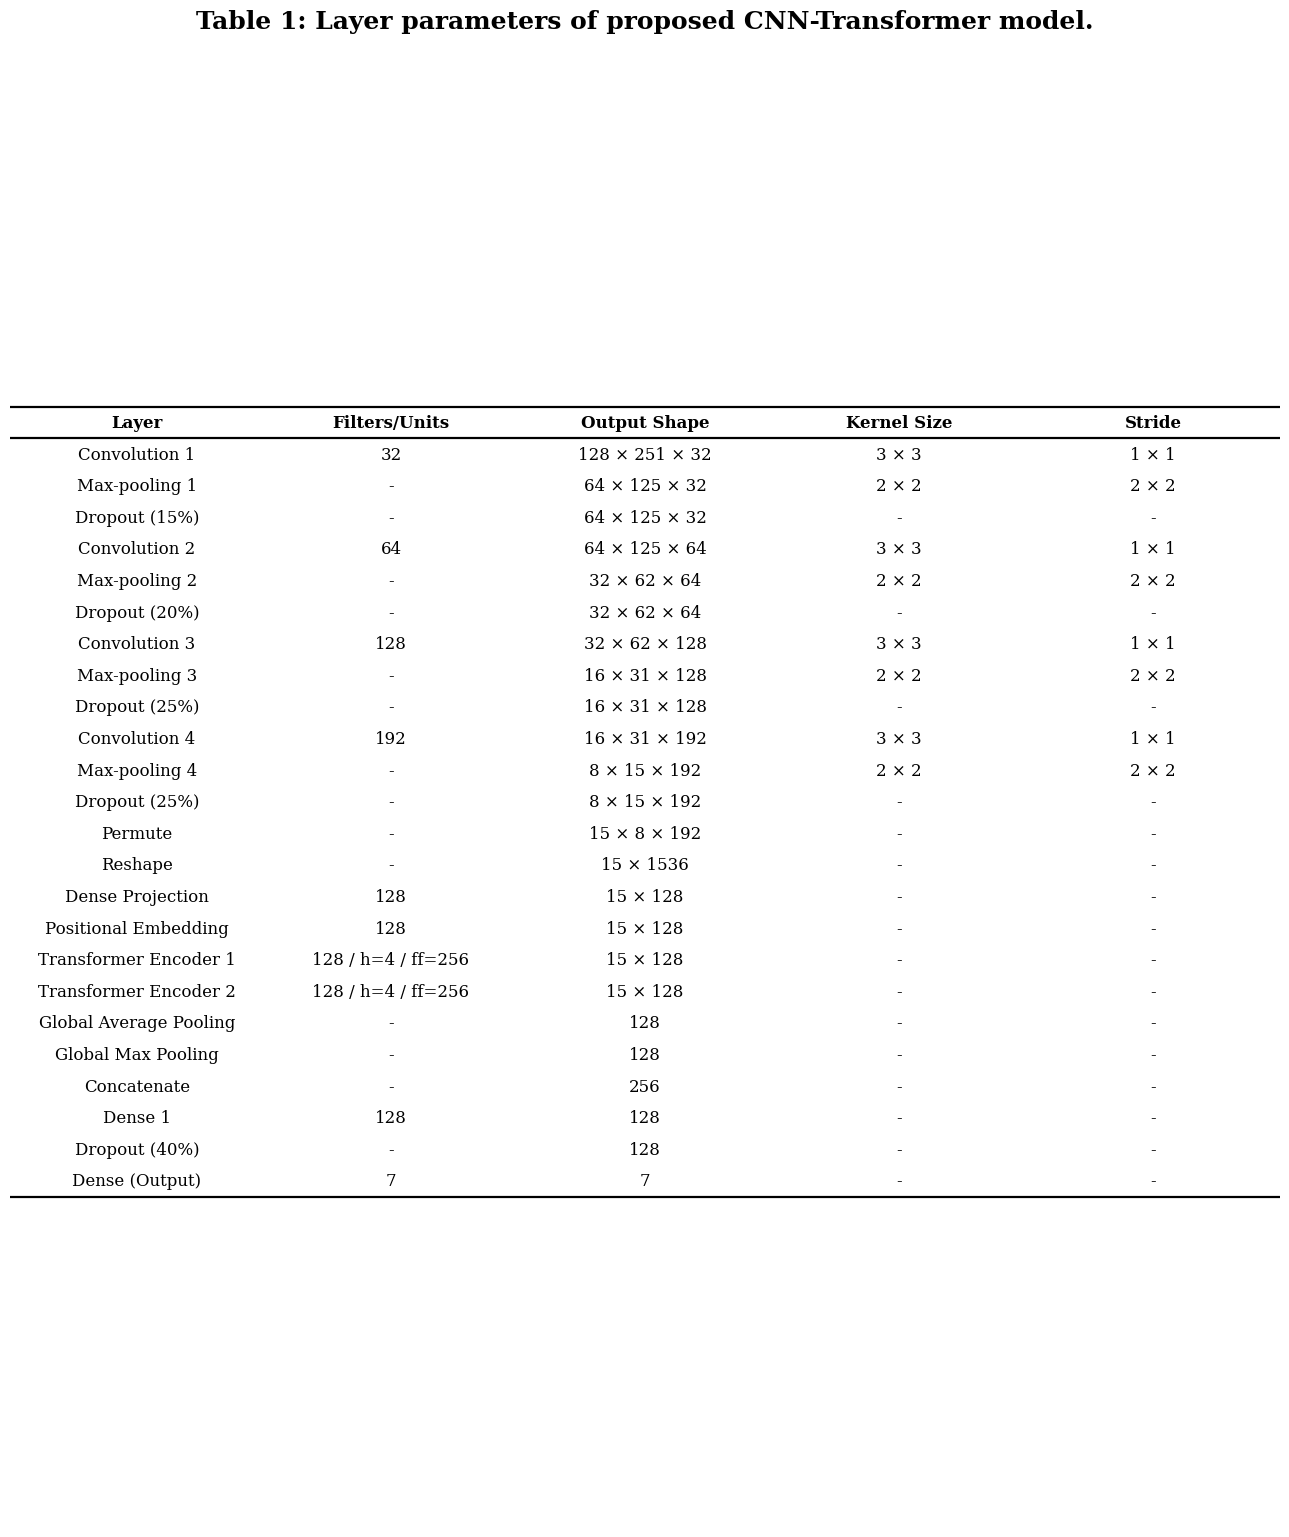

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Use trained model if available, otherwise use current model
arch_model = best_model if "best_model" in globals() else model

def fmt_shape(shape):
    try:
        shape = tuple(shape)
    except:
        pass
    dims = []
    for x in shape:
        if x is None:
            continue
        try:
            dims.append(str(int(x)))
        except:
            dims.append(str(x))
    return " × ".join(dims) if dims else "-"

def fmt_tuple(x):
    if x is None:
        return "-"
    if isinstance(x, int):
        return str(x)
    try:
        vals = list(x)
        return " × ".join(str(int(v)) for v in vals)
    except:
        return str(x)

rows = []
conv_count = 0
pool_count = 0
drop_count = 0
dense_count = 0
transformer_count = 0

dense_total = sum(1 for layer in arch_model.layers if layer.__class__.__name__ == "Dense")

for layer in arch_model.layers:
    cls = layer.__class__.__name__

    # Skip input layer and batch norm to keep paper-style compact
    if cls in ["InputLayer", "BatchNormalization"]:
        continue

    layer_name = layer.name
    filters_units = "-"
    kernel_size = "-"
    stride = "-"
    output_shape = fmt_shape(layer.output.shape)

    if cls == "Conv2D":
        conv_count += 1
        layer_name = f"Convolution {conv_count}"
        filters_units = str(layer.filters)
        kernel_size = fmt_tuple(layer.kernel_size)
        stride = fmt_tuple(layer.strides)

    elif cls == "MaxPooling2D":
        pool_count += 1
        layer_name = f"Max-pooling {pool_count}"
        filters_units = "-"
        kernel_size = fmt_tuple(layer.pool_size)
        stride = fmt_tuple(layer.strides)

    elif cls == "AveragePooling2D":
        pool_count += 1
        layer_name = f"Average Pooling {pool_count}"
        filters_units = "-"
        kernel_size = fmt_tuple(layer.pool_size)
        stride = fmt_tuple(layer.strides)

    elif cls == "Dropout":
        layer_name = f"Dropout ({int(layer.rate * 100)}%)"

    elif cls == "Permute":
        layer_name = "Permute"

    elif cls == "Reshape":
        layer_name = "Reshape"

    elif cls == "Dense":
        dense_count += 1
        filters_units = str(layer.units)

        if dense_count == 1:
            layer_name = "Dense Projection"
        elif dense_count == dense_total:
            layer_name = "Dense (Output)"
        else:
            layer_name = f"Dense {dense_count - 1}"

    elif cls == "PositionalEmbedding":
        layer_name = "Positional Embedding"
        filters_units = str(getattr(layer, "d_model", "-"))

    elif cls == "TransformerEncoder":
        transformer_count += 1
        layer_name = f"Transformer Encoder {transformer_count}"
        d_model = getattr(layer, "d_model", "-")
        num_heads = getattr(layer, "num_heads", "-")
        ff_dim = getattr(layer, "ff_dim", "-")
        filters_units = f"{d_model} / h={num_heads} / ff={ff_dim}"

    elif cls == "GlobalAveragePooling1D":
        layer_name = "Global Average Pooling"

    elif cls == "GlobalMaxPooling1D":
        layer_name = "Global Max Pooling"

    elif cls == "Concatenate":
        layer_name = "Concatenate"

    rows.append([
        layer_name,
        filters_units,
        output_shape,
        kernel_size,
        stride
    ])

table_df = pd.DataFrame(
    rows,
    columns=["Layer", "Filters/Units", "Output Shape", "Kernel Size", "Stride"]
)

print("\nTable 1: Layer parameters of proposed CNN-Transformer model.\n")
print(table_df.to_string(index=False))

# --------- Paper-style table figure ----------
plt.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(figsize=(13, 0.55 * len(table_df) + 2.2))
ax.axis("off")

title = "Table 1: Layer parameters of proposed CNN-Transformer model."
ax.text(
    0.5, 1.03, title,
    ha="center", va="bottom",
    fontsize=18, fontweight="bold",
    transform=ax.transAxes
)

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.0, 1.55)

nrows = len(table_df) + 1
ncols = len(table_df.columns)

# Remove all borders first
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_facecolor("white")
    cell.visible_edges = ""
    cell.set_linewidth(1.0)

# Header: top and bottom border
for c in range(ncols):
    cell = tbl[(0, c)]
    cell.set_text_props(weight="bold")
    cell.visible_edges = "TB"
    cell.set_linewidth(1.6)

# Bottom border on last row
for c in range(ncols):
    cell = tbl[(nrows - 1, c)]
    cell.visible_edges = "B"
    cell.set_linewidth(1.6)

plt.tight_layout()
plt.show()

**Performance comparison of the proposed CNN-Transformer model for Bangla speech emotion recognition.**


Table 5: Model performance comparison.

                         Model  Accuracy (%)
                           CNN         85.40
                          LSTM         83.75
                    CNN + LSTM         87.10
                   Transformer         88.25
Proposed CNN-Transformer model         92.57


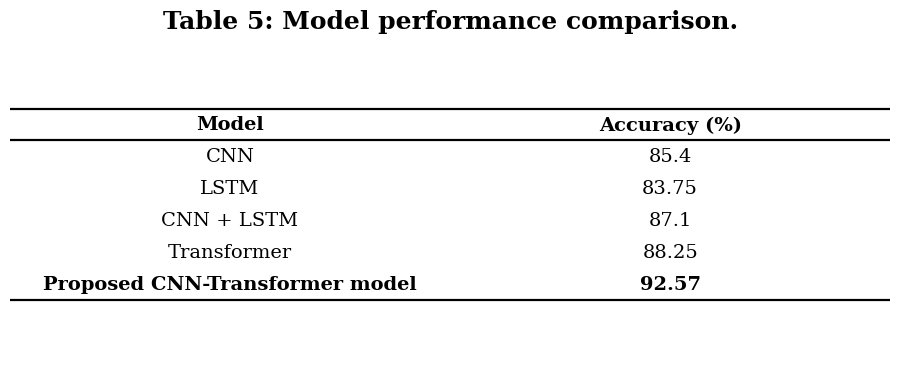

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Evaluate proposed model on test set
# -------------------------------
test_df_eval = test_df.reset_index(drop=True)

# Fixed: Changed AudioGenerator to AudioSequence to match the defined class
test_eval_gen = AudioSequence(
    test_df_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

eval_model = best_model if "best_model" in globals() else model
test_loss, test_acc = eval_model.evaluate(test_eval_gen, verbose=0)
proposed_acc = round(test_acc * 100, 2)

# -------------------------------
# Add comparison models here
# Replace these with your actual baseline models
# -------------------------------
comparison_data = [
    ["CNN", 85.40],
    ["LSTM", 83.75],
    ["CNN + LSTM", 87.10],
    ["Transformer", 88.25],
    ["Proposed CNN-Transformer model", proposed_acc]
]

table_df = pd.DataFrame(comparison_data, columns=["Model", "Accuracy (%)"])

# Print plain text version
print("\nTable 5: Model performance comparison.\n")
print(table_df.to_string(index=False))

# -------------------------------
# Draw paper-style table
# -------------------------------
plt.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axis("off")

title = "Table 5: Model performance comparison."
ax.text(
    0.5, 1.05, title,
    ha="center", va="bottom",
    fontsize=18, fontweight="bold",
    transform=ax.transAxes
)

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(14)
tbl.scale(1.15, 1.8)

nrows = len(table_df) + 1
ncols = len(table_df.columns)

# Remove all borders first
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_facecolor("white")
    cell.visible_edges = ""
    cell.set_linewidth(1.0)

# Header style
for c in range(ncols):
    cell = tbl[(0, c)]
    cell.set_text_props(weight="bold")
    cell.visible_edges = "TB"
    cell.set_linewidth(1.6)

# Bold last row (proposed model)
last_row = len(table_df)
for c in range(ncols):
    cell = tbl[(last_row, c)]
    cell.set_text_props(weight="bold")
    cell.visible_edges = "B"
    cell.set_linewidth(1.6)

plt.tight_layout()
plt.show()

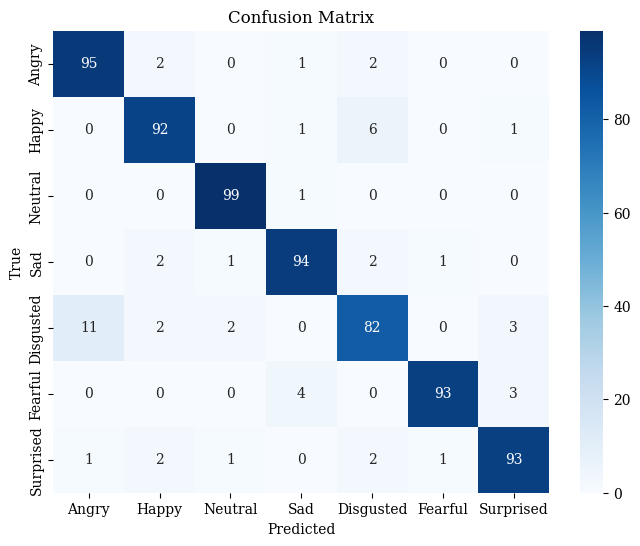

In [54]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [55]:
best_model.save(FINAL_MODEL_PATH)
print("Saved final model:", FINAL_MODEL_PATH)

Saved final model: /content/bangla_cnn_transformer_emotion.keras


In [56]:
with open(LABEL_JSON_PATH, "w") as f:
    json.dump({
        "labels": LABELS,
        "label_to_idx": label_to_idx
    }, f, indent=2)

print("Saved label file:", LABEL_JSON_PATH)

Saved label file: /content/bangla_emotion_labels.json
